# 5 · Tidal composites — your first satellite image


## Step 1 — Imports

Libraries for this page:

- **`pystac_client` + `planetary_computer`** — search and sign STAC assets (same as page 2).
- **`odc.stac`** — load Sentinel-2 bands into xarray/Dask arrays.
- **`rioxarray`** — GeoTIFF export and CRS handling.
- **`cache_utils`** — reuse the scene catalogue + tide tags from page 3.


In [9]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pystac_client
import planetary_computer as pc
import odc.stac
import rioxarray   # noqa: F401  — activates .rio accessor on xarray

from cache_utils import (
    load_or_compute_scenes,
    load_or_compute_tides,
    fetch_stac_items_for_scenes,
)

warnings.filterwarnings("ignore")
print("Imports OK.")


Imports OK.


## Step 2 — Configuration

Use the **same site centre** as pages 3–4 (`LON`, `LAT`, `SITE_NAME`, `START`, `END`).

| Variable | Role |
|---|---|
| `DELTA` | Half-width of the image box in degrees (~0.08° ≈ 8 km) |
| `LOW_PCT` / `HIGH_PCT` | Percentile cut-offs for low / high tide scenes (typically 5–15%) |
| `MAX_CLOUD` | Scene-level cloud ceiling — tighter than page 3 for cleaner composites |
| `N_SCENES_MIN` | Warn if fewer scenes than this per composite |
| `OVERWRITE_SCENES` | Re-query PC scene list (needed if page 3 had S2 disabled) |
| `OVERWRITE_COMPOSITE` | Re-download pixels even if GeoTIFF cache exists |


In [10]:
# === EDIT THESE ===
LON        = 4.81050
LAT        = 52.98886
SITE_NAME  = "WaddenSea"

DELTA      = 0.08      # degrees; half-width of the AOI box (~8 km)

TIDE_DIR   = "./tide_models"
TIDE_MODEL = "FES2022"
START      = "2023-01-01"
END        = "2023-12-31"

# Sensor toggles (match page 3 when possible)
USE_SENTINEL2 = True
USE_LANDSAT8  = True
USE_LANDSAT9  = True
SENSORS = [s for s, on in [
    ("Sentinel-2", USE_SENTINEL2),
    ("Landsat 8",  USE_LANDSAT8),
    ("Landsat 9",  USE_LANDSAT9),
] if on]

LOW_PCT    = 15        # lowest X% of observed tide heights → low-tide composite
HIGH_PCT   = 15        # highest X% → high-tide composite
MAX_CLOUD  = 20        # scene-level STAC cloud ceiling (pre-filter)
COMPOSITE_RES = 30     # output grid (m); S2 resampled, Landsat native
MIN_CLEAR_FRAC = 0.35  # min share of clear scenes per pixel (drops speckle)
N_SCENES_MIN = 3

OVERWRITE_SCENES    = True
OVERWRITE_COMPOSITE = True

# -------------------------------------------------------
os.environ["EO_TIDES_TIDE_MODELS"] = TIDE_DIR
BBOX = (LON - DELTA, LAT - DELTA, LON + DELTA, LAT + DELTA)
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

print(f"Site    : {SITE_NAME}  ({LAT:.4f} N, {LON:.4f} E)")
print(f"AOI     : {BBOX}")
print(f"Window  : {START} to {END}")
print(f"Sensors : {', '.join(SENSORS) or '(none!)'}")
print(f"Low tide  : lowest  {LOW_PCT}% of observed tide heights")
print(f"High tide : highest {HIGH_PCT}% of observed tide heights")


Site    : WaddenSea  (52.9889 N, 4.8105 E)
AOI     : (4.7305, 52.908860000000004, 4.8905, 53.06886)
Window  : 2023-01-01 to 2023-12-31
Sensors : Sentinel-2, Landsat 8, Landsat 9
Low tide  : lowest  15% of observed tide heights
High tide : highest 15% of observed tide heights


## Step 3 — Load scene cache and select tidal subsets

We reuse `load_or_compute_scenes` from page 3 for the sensors you enabled above
(Sentinel-2 + Landsat 8/9). More sensors → more scenes → **better cloud filling**
in the median composite.

Each row has a **tide_height** tag from FES2022. We split scenes into:

- **Low-tide set** — tide height ≤ the `LOW_PCT` percentile
- **High-tide set** — tide height ≥ the `(100 − HIGH_PCT)` percentile


In [11]:
scenes_df = load_or_compute_scenes(
    lon=LON, lat=LAT,
    start=START, end=END,
    site_name=SITE_NAME,
    tide_model=TIDE_MODEL,
    tide_dir=TIDE_DIR,
    max_cloud=MAX_CLOUD,
    delta=DELTA,
    overwrite=OVERWRITE_SCENES,
    sensors=SENSORS,
)

if "time" not in scenes_df.columns:
    scenes_df = scenes_df.reset_index()

usable = scenes_df[
    scenes_df["sensor"].isin(SENSORS) &
    (scenes_df["cloud_cover"].fillna(100) < MAX_CLOUD) &
    scenes_df["tide_height"].notna()
].copy()

print(f"Scenes available ({', '.join(SENSORS)}): {len(usable)}")
for sensor in SENSORS:
    n = (usable["sensor"] == sensor).sum()
    print(f"  {sensor:12s}: {n}")

low_thresh  = usable["tide_height"].quantile(LOW_PCT / 100)
high_thresh = usable["tide_height"].quantile(1 - HIGH_PCT / 100)

low_scenes  = usable[usable["tide_height"] <= low_thresh]
high_scenes = usable[usable["tide_height"] >= high_thresh]

print(f"\nLow-tide  threshold : ≤ {low_thresh:+.3f} m  →  {len(low_scenes)} scenes")
print(f"High-tide threshold : ≥ {high_thresh:+.3f} m  →  {len(high_scenes)} scenes")

flags = []
if len(usable) == 0:
    flags.append("NO SCENES — check USE_* toggles and set OVERWRITE_SCENES=True")
if len(low_scenes) < N_SCENES_MIN:
    flags.append(f"FEW LOW-TIDE SCENES ({len(low_scenes)}) — raise LOW_PCT or enable more sensors")
if len(high_scenes) < N_SCENES_MIN:
    flags.append(f"FEW HIGH-TIDE SCENES ({len(high_scenes)}) — raise HIGH_PCT or extend END")

status = "OK" if not flags else "WARNING"
print()
print("=" * 60)
print(f"[{status}] Scene selection — {SITE_NAME}")
print("=" * 60)
for f in flags:
    print(f"  ⚠  {f}")
if not flags:
    print("  ✓  Enough low- and high-tide scenes for composites.")
if status == "OK":
    print("\nOVERALL: GOOD — proceed to pixel download (Step 5).")
elif len(low_scenes) >= 1 and len(high_scenes) >= 1:
    print("\nOVERALL: CAUTION — composites may be noisy; consider tuning percentiles.")
else:
    print("\nOVERALL: POOR — fix scene selection before downloading pixels.")
print("=" * 60)


  Querying PC for Sentinel-2 ...
  Querying PC for Landsat 8 ...
  Querying PC for Landsat 9 ...
  Loaded from cache ← cache/tides_WaddenSea_2023-01-01_2023-12-31.parquet  (17,473 rows)
  Tagged 42/42 scenes with tide heights (±30 min)
  Cached → cache/scenes_WaddenSea_s2-l8-l9_2023-01-01_2023-12-31.parquet  (42 rows)
Scenes available (Sentinel-2, Landsat 8, Landsat 9): 42
  Sentinel-2  : 26
  Landsat 8   : 8
  Landsat 9   : 8

Low-tide  threshold : ≤ -0.479 m  →  7 scenes
High-tide threshold : ≥ +0.628 m  →  8 scenes

[OK] Scene selection — WaddenSea
  ✓  Enough low- and high-tide scenes for composites.

OVERALL: GOOD — proceed to pixel download (Step 5).


### Interpreting Step 3

| Output | Good sign | Warning sign |
|---|---|---|
| **S-2 scenes available** | Dozens over 1–3 years | 0 → wrong cache or S2 disabled on page 3 |
| **Low / high counts** | Both ≥ 5 | < 3 → raise `LOW_PCT`/`HIGH_PCT` or extend `END` |
| **Thresholds (m, MSL)** | Span most of page 3 HAT–LAT range | Both thresholds near zero → tide tags missing |

The percentile method is **relative to observed passes**, not absolute LAT/HAT.
That is intentional: we want the driest and wettest **satellite** views available,
not theoretical extremes never imaged.


## Step 4 — Visual check: which scenes were selected?

Grey **curve** = continuous FES2022 tide (30 min). **Dots** = satellite overpasses
coloured by tidal class (blue = low, red = high). This matches the style of page 3.


  Loaded from cache ← cache/tides_WaddenSea_2023-01-01_2023-12-31.parquet  (17,473 rows)


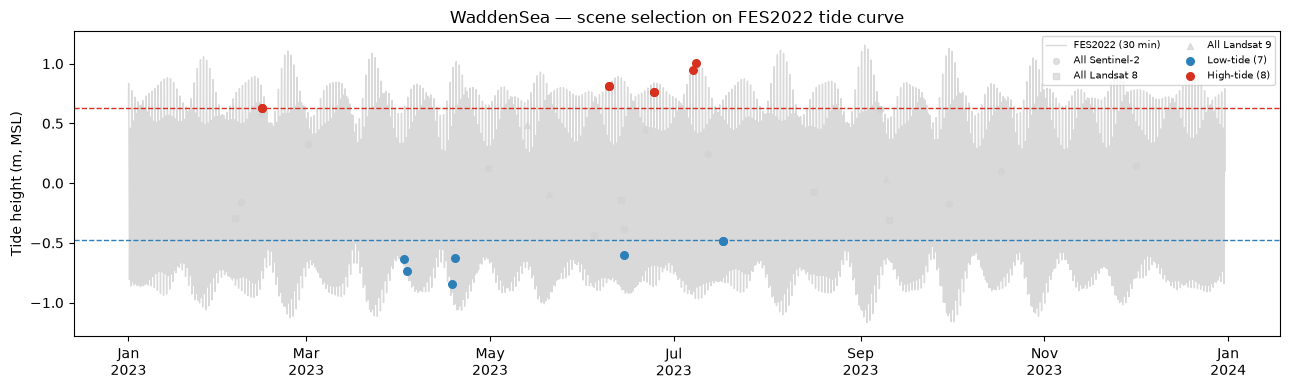

In [12]:
# FES2022 tide curve (background)
tide_series = load_or_compute_tides(
    lon=LON, lat=LAT,
    start=START, end=END,
    site_name=SITE_NAME,
    tide_model=TIDE_MODEL,
    tide_dir=TIDE_DIR,
    overwrite=False,
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(tide_series.index, tide_series.values, color="#d9d9d9", lw=1.0, zorder=0,
        label="FES2022 (30 min)")

# Marker shapes per sensor
sensor_style = {
    "Sentinel-2": "o",
    "Landsat 8":  "s",
    "Landsat 9":  "^",
}

for sensor in SENSORS:
    sub = usable[usable["sensor"] == sensor]
    if sub.empty:
        continue
    ax.scatter(sub["time"], sub["tide_height"], s=18, marker=sensor_style.get(sensor, "o"),
               color="lightgrey", alpha=0.7, label=f"All {sensor}", zorder=1)

ax.scatter(low_scenes["time"],  low_scenes["tide_height"],  s=30,
           color="#2c7fb8", label=f"Low-tide ({len(low_scenes)})", zorder=3)
ax.scatter(high_scenes["time"], high_scenes["tide_height"], s=30,
           color="#d7301f", label=f"High-tide ({len(high_scenes)})", zorder=3)
ax.axhline(low_thresh,  color="#2c7fb8", lw=1, ls="--")
ax.axhline(high_thresh, color="#d7301f", lw=1, ls="--")
ax.set_ylabel("Tide height (m, MSL)")
ax.set_title(f"{SITE_NAME} — scene selection on FES2022 tide curve")
ax.legend(fontsize=7, ncol=2, loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.tight_layout()
plt.show()


### Interpreting Step 4

- **Blue and red dots at opposite ends of the y-axis** — good separation; composites will contrast.
- **Clusters only in the middle** — poor tidal sampling; return to page 3 or extend the date range.
- **Grey FES2022 curve** — full tidal signal; dots should sit on this curve (same tide tag as page 3).
- **Gaps in time** — normal; Landsat (~16 d) + Sentinel-2 (~5 d) together fill gaps better.
- **Horizontal dashed lines** — the percentile cut-offs; scenes on the line are tied and all included.


## Step 5 — Load pixels from Planetary Computer

For each tidal class we download **red, green, blue** plus a **cloud mask band**:

| Sensor | Cloud mask | Mask rule |
|---|---|---|
| **Sentinel-2** | `SCL` | mask classes 0, 1, 3, 8, 9, 10 |
| **Landsat 8/9** | `qa_pixel` | mask cloud (bit 3) and shadow (bit 4) |

Scenes from all enabled sensors are loaded on a common **30 m grid**, masked, then
combined in a **median composite**. Cloudy pixels become NaN — the median uses
only clear observations from any sensor/date.

**Set `OVERWRITE_COMPOSITE = True`** after adding Landsat or changing sensors.


In [13]:
PC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
catalog = pystac_client.Client.open(PC_URL, modifier=pc.sign_inplace)

SCL_MASK_VALUES = {0, 1, 3, 8, 9, 10}
S2_BASELINE_CUTOFF = np.datetime64("2022-01-25")


def _ensure_time_dim(ds: xr.Dataset) -> xr.Dataset:
    if "time" not in ds.dims:
        ds = ds.expand_dims("time")
    return ds


def harmonize_s2(ds: xr.Dataset) -> xr.Dataset:
    """Subtract +1000 DN offset for Sentinel-2 Processing Baseline >= 04.00."""
    bands = [v for v in ds.data_vars if v != "SCL"]
    if not bands:
        return ds

    def _subtract_1000(data: xr.Dataset) -> xr.Dataset:
        out = data.copy()
        out[bands] = out[bands] - 1000
        return out.clip(min=0)

    if "time" not in ds.dims:
        if "time" in ds.coords:
            t = np.datetime64(ds.coords["time"].values)
            return _subtract_1000(ds) if t > S2_BASELINE_CUTOFF else ds.clip(min=0)
        return ds.clip(min=0)

    times = ds.time.values
    if np.all(times <= S2_BASELINE_CUTOFF):
        return ds.clip(min=0)
    if np.all(times > S2_BASELINE_CUTOFF):
        return _subtract_1000(ds)

    mask = xr.DataArray(times > S2_BASELINE_CUTOFF, dims=["time"], coords={"time": ds.time})
    out = ds.copy()
    for band in bands:
        out[band] = xr.where(mask, out[band] - 1000, out[band])
    return out.clip(min=0)


def apply_s2_cloud_mask(ds: xr.Dataset) -> xr.Dataset:
    scl = ds["SCL"]
    cloud_mask = xr.zeros_like(scl, dtype=bool)
    for val in SCL_MASK_VALUES:
        cloud_mask = cloud_mask | (scl == val)
    return ds.where(~cloud_mask).drop_vars("SCL", errors="ignore")


def apply_landsat_cloud_mask(ds: xr.Dataset) -> xr.Dataset:
    qa = ds["qa_pixel"]
    clear = np.bitwise_and(qa, (1 << 3) | (1 << 4)) == 0
    return ds.where(clear).drop_vars("qa_pixel", errors="ignore")


def load_sensor_stack(scenes: pd.DataFrame, sensor: str) -> xr.Dataset | None:
    if scenes.empty:
        return None
    items = fetch_stac_items_for_scenes(catalog, scenes, BBOX)
    if not items:
        print(f"  ⚠  No STAC items for {sensor} ({len(scenes)} scenes)")
        return None

    print(f"  {sensor}: loading {len(items)} scenes at {COMPOSITE_RES} m ...")

    if sensor == "Sentinel-2":
        ds = odc.stac.load(
            items,
            bands=["red", "green", "blue", "SCL"],
            bbox=BBOX,
            resolution=COMPOSITE_RES,
            groupby="time",
            chunks={"x": 1024, "y": 1024},
            resampling={"SCL": "nearest", "*": "cubic"},
            patch_url=pc.sign,
            dtype="uint16",
            nodata=0,
        ).compute()
        ds = harmonize_s2(ds)
        ds = apply_s2_cloud_mask(ds)
        rgb = [b for b in ("red", "green", "blue") if b in ds]
        ds[rgb] = ds[rgb] / 10000.0
    else:
        ds = odc.stac.load(
            items,
            bands=["red", "green", "blue", "qa_pixel"],
            bbox=BBOX,
            resolution=COMPOSITE_RES,
            groupby="time",
            chunks={"x": 512, "y": 512},
            resampling={"qa_pixel": "nearest", "*": "cubic"},
            patch_url=pc.sign,
            dtype="uint16",
            nodata=0,
        ).compute()
        ds = apply_landsat_cloud_mask(ds)
        for band in ("red", "green", "blue"):
            if band in ds:
                ds[band] = (ds[band] * 0.0000275 - 0.2).clip(min=0)

    return _ensure_time_dim(ds)


def load_composite(selected_scenes: pd.DataFrame, label: str):
    """Return (rgb Dataset, clear_fraction DataArray) or (None, None)."""
    cache_tif = CACHE_DIR / f"composite_{SITE_NAME}_{label}.tif"
    cache_frac = CACHE_DIR / f"composite_{SITE_NAME}_{label}_clearfrac.tif"

    if cache_tif.exists() and cache_frac.exists() and not OVERWRITE_COMPOSITE:
        print(f"Loading {label} composite from cache: {cache_tif}")
        import rioxarray as rxr
        rgb = rxr.open_rasterio(cache_tif).assign_coords(band=["red", "green", "blue"])
        frac = rxr.open_rasterio(cache_frac)
        return rgb, frac

    stacks = []
    for sensor in SENSORS:
        part = selected_scenes[selected_scenes["sensor"] == sensor]
        stack = load_sensor_stack(part, sensor)
        if stack is not None:
            stacks.append(stack)

    if not stacks:
        print(f"⚠  No pixel data loaded for {label} composite.")
        return None, None

    ds = xr.concat(stacks, dim="time") if len(stacks) > 1 else stacks[0]
    ds = _ensure_time_dim(ds)

    rgb_vars = ds[["red", "green", "blue"]]
    valid = rgb_vars["red"].notnull()
    n_clear = valid.sum(dim="time")
    n_times = int(ds.sizes["time"])
    clear_fraction = (n_clear / n_times).astype("float32")

    composite = rgb_vars.median(dim="time", skipna=True).clip(min=0, max=1)
    # Drop salt-and-pepper pixels (single-scene cloud gaps)
    composite = composite.where(clear_fraction >= MIN_CLEAR_FRAC)
    clear_fraction = clear_fraction.where(clear_fraction >= MIN_CLEAR_FRAC)

    rgb = xr.concat([composite["red"], composite["green"], composite["blue"]], dim="band")
    rgb = rgb.assign_coords(band=["red", "green", "blue"])
    rgb.rio.to_raster(cache_tif, dtype="float32")
    clear_fraction.rio.to_raster(cache_frac, dtype="float32")
    print(f"Saved: {cache_tif}  (+ clear-fraction layer)")

    rgb_da = xr.concat([composite["red"], composite["green"], composite["blue"]], dim="band")
    rgb_da = rgb_da.assign_coords(band=["red", "green", "blue"])
    if hasattr(composite, "rio"):
        rgb_da = rgb_da.rio.write_crs(composite.rio.crs, inplace=False)
        rgb_da = rgb_da.rio.write_transform(composite.rio.transform(), inplace=False)
    clear_fraction = clear_fraction.rio.write_crs(composite.rio.crs, inplace=False)
    clear_fraction = clear_fraction.rio.write_transform(composite.rio.transform(), inplace=False)
    return rgb_da, clear_fraction


low_ds,  low_clear  = load_composite(low_scenes,  "lowtide")
high_ds, high_clear = load_composite(high_scenes, "hightide")


  Sentinel-2: loading 2 scenes at 30 m ...
  Landsat 8: loading 2 scenes at 30 m ...
  Landsat 9: loading 3 scenes at 30 m ...
Saved: cache/composite_WaddenSea_lowtide.tif  (+ clear-fraction layer)
  Sentinel-2: loading 6 scenes at 30 m ...
  Landsat 8: loading 1 scenes at 30 m ...
  Landsat 9: loading 1 scenes at 30 m ...
Saved: cache/composite_WaddenSea_hightide.tif  (+ clear-fraction layer)


### Interpreting Step 5

| Message | Meaning |
|---|---|
| `Loading … from cache` | GeoTIFF already exists — instant reload |
| `Loading N items …` | Downloading from Planetary Computer (slow) |
| `No STAC items matched` | Old scene cache or STAC lookup failed — set `OVERWRITE_SCENES=True` once |
| `Saved: cache/composite_…` | Success — cached for next run |

**First run is slow; second run is fast.** Set `OVERWRITE_COMPOSITE = True` only when you
change AOI, percentiles, or cloud settings.


## Step 6 — Display the composites

RGB with percentile stretch. Pixels need **`MIN_CLEAR_FRAC`** of input scenes
clear (drops cloud speckle) plus a 3×3 neighbour check. Gaps are **dark blue-grey**,
never white dots. Set `OVERWRITE_COMPOSITE=True` in Step 2 after changing `MIN_CLEAR_FRAC`.


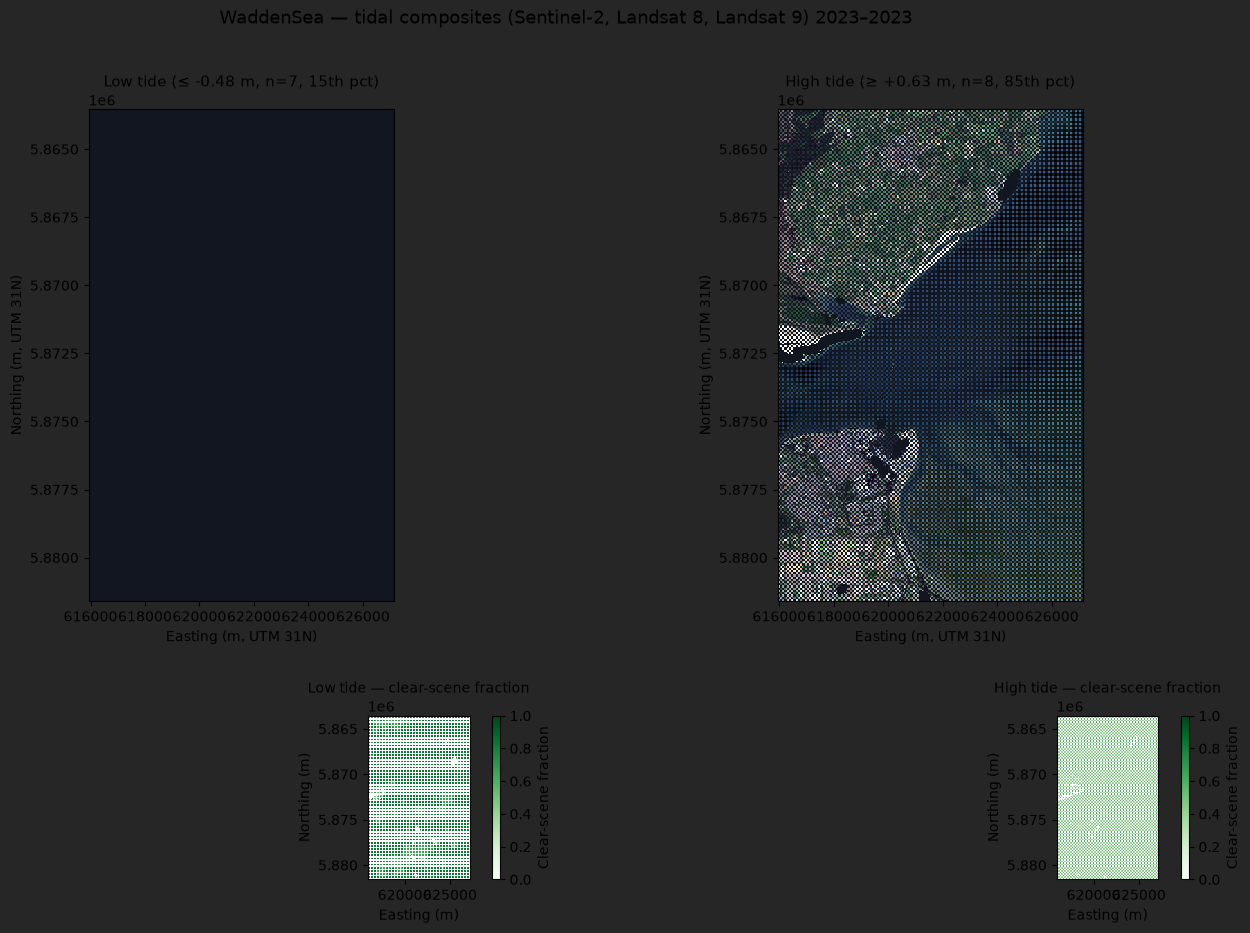

Saved: WaddenSea_tidal_composites.png


In [15]:
def _suppress_speckles(show: np.ndarray, min_neighbors: int = 5) -> np.ndarray:
    """Remove isolated valid pixels (3×3 window must have ≥ min_neighbors)."""
    pad = np.pad(show.astype(np.uint8), 1, mode="constant", constant_values=0)
    h, w = show.shape
    counts = np.zeros((h, w), dtype=np.int16)
    for i in range(3):
        for j in range(3):
            counts += pad[i:i + h, j:j + w]
    return counts >= min_neighbors


def percentile_stretch_rgb(r, g, b,
                             low: float = 2.0,
                             high: float = 98.0) -> np.ndarray:
    valid = np.isfinite(r) & np.isfinite(g) & np.isfinite(b) & (r > 0) & (g > 0) & (b > 0)
    if not valid.any():
        return np.zeros((*r.shape, 3), dtype=float)

    out = np.zeros((*r.shape, 3), dtype=float)
    for i, band in enumerate([r, g, b]):
        v = band[valid]
        lo, hi = np.percentile(v, low), np.percentile(v, high)
        if hi <= lo:
            continue
        scaled = np.clip((band - lo) / (hi - lo), 0, 1)
        out[..., i] = np.where(valid, scaled, 0.0)
    return out


def _as_geotiff_da(ds) -> xr.DataArray:
    if isinstance(ds, xr.Dataset):
        rgb = xr.concat([ds["red"], ds["green"], ds["blue"]], dim="band")
        return rgb.assign_coords(band=["red", "green", "blue"])
    if "band" not in ds.dims:
        raise ValueError("Expected band dimension")
    band_vals = [str(v).lower() for v in ds.coords["band"].values]
    if not {"red", "green", "blue"}.issubset(set(band_vals)):
        return ds.assign_coords(band=["red", "green", "blue"])
    return ds


def _imshow_extent(da: xr.DataArray):
    b = da.rio.bounds()
    if isinstance(b, tuple):
        left, bottom, right, top = b
    else:
        left, right, bottom, top = b.left, b.right, b.bottom, b.top
    return [left, right, bottom, top], "lower"


def _clear_frac_array(clear_frac) -> np.ndarray | None:
    if clear_frac is None:
        return None
    arr = clear_frac.values
    return arr[0] if arr.ndim == 3 else arr


def plot_rgb(ax, ds, title: str, clear_frac=None):
    """Plot north-up RGB; gaps are dark (never white speckles)."""
    da = _as_geotiff_da(ds)
    r = da.sel(band="red").values.astype(float)
    g = da.sel(band="green").values.astype(float)
    b = da.sel(band="blue").values.astype(float)
    rgb = percentile_stretch_rgb(r, g, b)

    show = (r > 0) & (g > 0) & (b > 0) & np.isfinite(r)
    frac = _clear_frac_array(clear_frac)
    if frac is not None:
        show &= frac >= MIN_CLEAR_FRAC
    show = _suppress_speckles(show)

    bg = np.array([0.07, 0.09, 0.13])
    display = np.tile(bg, (*rgb.shape[:2], 1))
    display[show] = np.clip(rgb[show], 0, 1)

    extent, origin = _imshow_extent(da)
    ax.imshow(display, origin=origin, extent=extent, aspect="equal",
              interpolation="nearest")
    ax.set_facecolor(bg)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Easting (m, UTM 31N)")
    ax.set_ylabel("Northing (m, UTM 31N)")


def plot_clear_fraction(ax, clear_frac, title: str):
    if clear_frac is None or not hasattr(clear_frac, "rio"):
        ax.set_visible(False)
        return
    frac = _clear_frac_array(clear_frac)
    extent, origin = _imshow_extent(clear_frac)
    im = ax.imshow(frac, origin=origin, extent=extent, aspect="equal",
                   vmin=0, vmax=1, cmap="Greens", interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Clear-scene fraction")


fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[3, 1], hspace=0.35, wspace=0.25)
fig.patch.set_facecolor("0.15")

ax_low  = fig.add_subplot(gs[0, 0])
ax_high = fig.add_subplot(gs[0, 1])
ax_cl   = fig.add_subplot(gs[1, 0])
ax_ch   = fig.add_subplot(gs[1, 1])

plot_rgb(ax_low, low_ds,
         f"Low tide (≤ {low_thresh:+.2f} m, n={len(low_scenes)}, {LOW_PCT}th pct)",
         clear_frac=low_clear)
plot_rgb(ax_high, high_ds,
         f"High tide (≥ {high_thresh:+.2f} m, n={len(high_scenes)}, {100-HIGH_PCT}th pct)",
         clear_frac=high_clear)
plot_clear_fraction(ax_cl, low_clear,  "Low tide — clear-scene fraction")
plot_clear_fraction(ax_ch, high_clear, "High tide — clear-scene fraction")

fig.suptitle(
    f"{SITE_NAME} — tidal composites ({', '.join(SENSORS)}) {START[:4]}–{END[:4]}",
    fontsize=13, y=0.98,
)
fig.savefig(f"{SITE_NAME}_tidal_composites.png", dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {SITE_NAME}_tidal_composites.png")


### Interpreting Step 6

Ask yourself:

1. **Does low tide show more exposed sediment** (lighter tones) than high tide?
2. **Is water darker and more uniform** in the high-tide panel?
3. **Are there large white/black holes?** → persistent cloud; tighten `MAX_CLOUD` or add scenes.
4. **Do both panels look identical?** → poor tidal separation; revisit Step 3 percentiles.

| Visual cue | Low-tide panel | High-tide panel |
|---|---|---|
| **Intertidal flats** | Visible sand/mud banks | Submerged (dark, like open water) |
| **Permanent water** | Dark channels | Dark channels |
| **Salt marsh / land** | Green/brown, stable between panels | Same |

This is qualitative — page 7 assigns **metres elevation** to every pixel.


## Step 7 — Intertidal footprint (ΔNDWI, optional)

Where does the image change most between low and high tide? We use a simple
**green − red** normalised difference (NDWI proxy) and subtract low from high.

**Positive values (red in the map)** = dry at low tide, wet at high tide → **intertidal zone**.


In [ ]:
if low_ds is not None and high_ds is not None:

    def ndwi_from_rgb(ds):
        da = _as_geotiff_da(ds)
        g = da.sel(band="green").values.astype(float)
        r = da.sel(band="red").values.astype(float)
        return (g - r) / (g + r + 1e-6)

    diff = ndwi_from_rgb(high_ds) - ndwi_from_rgb(low_ds)
    ref = _as_geotiff_da(high_ds)
    extent, origin = _imshow_extent(ref)

    fig, ax = plt.subplots(figsize=(9, 7))
    vmax = np.nanpercentile(np.abs(diff[np.isfinite(diff)]), 98)
    im = ax.imshow(diff, origin=origin, extent=extent, aspect="equal",
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
    cbar = fig.colorbar(im, ax=ax, shrink=0.75)
    cbar.set_label("ΔNDWI proxy (high − low)\nPositive = intertidal")
    ax.set_title(f"{SITE_NAME} — intertidal footprint")
    ax.set_xlabel("Easting (m, UTM 31N)")
    ax.set_ylabel("Northing (m, UTM 31N)")
    fig.tight_layout()
    fig.savefig(f"{SITE_NAME}_intertidal_footprint.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {SITE_NAME}_intertidal_footprint.png")
else:
    print("Skipping ΔNDWI — run Step 5 first.")


### Interpreting Step 7

| Pattern | Meaning |
|---|---|
| **Red band along channel margins** | Classic intertidal footprint — good sign |
| **Patchy red** | Cloud gaps or mixed pixels — normal with few scenes |
| **Uniform blue everywhere** | Little tidal signal — check scene selection |
| **Red on land** | Can happen on bright agricultural fields — ignore off-coast |

This map is a **diagnostic**, not a product. Page 6 produces the quantitative elevation model.


## Step 8 — Export GeoTIFF for GIS

Copy cached composites to the repo root with descriptive filenames.


In [ ]:
import shutil

for label in ("lowtide", "hightide"):
    src = CACHE_DIR / f"composite_{SITE_NAME}_{label}.tif"
    dst = Path(f"{SITE_NAME}_{label}_composite.tif")
    if src.exists():
        shutil.copy(src, dst)
        print(f"Exported: {dst}")
        try:
            import rioxarray as rxr
            arr = rxr.open_rasterio(dst)
            print(f"  CRS: {arr.rio.crs}  |  shape: {arr.shape}")
        except Exception as e:
            print(f"  (could not read CRS: {e})")
    else:
        print(f"Not found: {src}")


## Step 9 — What you have seen (recap)

1. **Scene selection (Steps 3–4)** — lowest/highest tide passes (S2 + Landsat) on FES2022 background.
2. **Pixel download (Step 5)** — RGB + SCL/QA cloud mask; multi-sensor median at 30 m.
3. **Visual composites (Step 6)** — low vs high tide side by side.
4. **Footprint check (Step 7)** — ΔNDWI proxy outlines wetting/drying zone.
5. **GIS export (Step 8)** — GeoTIFF files with CRS metadata.

### Output files

| File | Content |
|---|---|
| `{site}_lowtide_composite.tif` | Median RGB at lowest tide percentile |
| `{site}_hightide_composite.tif` | Median RGB at highest tide percentile |
| `{site}_tidal_composites.png` | Side-by-side display figure |
| `{site}_intertidal_footprint.png` | ΔNDWI difference map |

### Simple go / no-go before page 6 (NDWI)

| Situation | Interpretation |
|---|---|
| Clear low/high contrast + red intertidal band | **Proceed** to elevation mapping |
| Composites OK but patchy clouds | **Proceed with caution** — page 7 uses more scenes |
| < 3 scenes per class or identical panels | **Stop** — fix sampling on page 3 first |
| No S2 in cache | Set `OVERWRITE_SCENES = True` or enable S2 on page 3 |

### Cache files

```
cache/
  scenes_<site>_s2_<start>_<end>.parquet     ← Step 3 (S2 metadata + tide tags)
  composite_<site>_lowtide.tif              ← Step 5
  composite_<site>_hightide.tif             ← Step 5
  composite_<site>_lowtide_clearfrac.tif      ← cloud-free fraction (0–1)
```

### Tuning tips

- **Raise `LOW_PCT` / `HIGH_PCT`** (e.g. 15%) — more scenes, less extreme tidal contrast.
- **Lower `MAX_CLOUD`** (e.g. 40) — cleaner sky, fewer scenes.
- **Extend `END`** — more revisits, especially for cloudy coasts.

**Next:** [6 · NDWI](06_ndwi.ipynb) — how wet/dry maps to height. Then [7 · Elevation](07_elevation.ipynb) — full intertidal DEM with `intertidal.elevation()`.
